# Scenario 1 Exfiltrator Anomaly Inspector

This notebook helps you sanity‑check the **Isolation Forest + z‑score anomaly detector** against the known Scenario 1 exfiltrators in r5.2.

What it does:

* Loads the Scenario 1 exfiltrator timeline from `answers/insiders.csv`
* Loads window‑level anomaly scores + z‑scores from `out/<REL>/anomaly/window_zscores.parquet`
* Loads anomaly alerts from a chosen `alerts.ndjson` produced by `run_loop.py`
* Lets you inspect **one S1 user at a time**:
  * their exfil start/end
  * their anomaly scores and z‑scores over time
  * which days the anomaly detector actually fired alerts


# Anomaly Detector Evaluation Summary (Scenario 1, r5.2)

This notebook evaluates the Isolation Forest + z-score anomaly detector using:
- Scenario 1 insider exfiltration timelines
- Window-level anomaly scores (`window_zscores.parquet`)
- Anomaly alerts generated by the real `run_loop.py`

## Key Findings

### Detection of Actual Exfiltration
- **Recall on exfiltration days:** 78.4%  
- **True Positives (TP):** 116  
- **False Negatives (FN):** 32  

### Early Warning Signals
- **Early-warning positives (EWP):** 42  
- **Insiders receiving early warning:** 14  
- **Median lead time:** 2 days  
- **Maximum lead time:** 14 days  

The detector is not only detecting active exfiltration but is often signaling *before* the window begins.

### Precision
Two precision scores are reported:
- **Strict precision (TP/(TP+FP)):** 0.462  
- **Precision including early warnings (TP+EWP)/(TP+EWP+FP):** 0.539  

Including early warnings gives a more realistic assessment of useful signal.

### Noise on Non-Insiders
- **Total non-insiders evaluated:** 1,971  
- **Users with ≥1 anomaly alert:** 340 (17.25%)  
- **Median false-positive rate:** 0.000  
- **Mean false-positive rate:** 0.052  
- **75% of non-insiders:** 0 alerts  
- **Noise is concentrated in ~1% of users** with chronically irregular behavior.

### Interpretation
The anomaly detector is *quiet* across most of the population but consistently flags insiders during and before exfiltration.  
This behavior is desirable for an ensemble system: broad stability + concentrated early-warning signals around real threats.



In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

# Figure out repo root (handles being run from notebooks/)
ROOT = Path.cwd().resolve()
if not (ROOT / "release.txt").exists():
    ROOT = ROOT.parent

print("Notebook ROOT:", ROOT)

# Read release tag (e.g., 'r5.2')
REL = (ROOT / "release.txt").read_text().strip()

# Core artifacts
WINDOW_ZSCORES = ROOT / f"out/{REL}/anomaly/window_zscores.parquet"
DAILY = ROOT / f"out/{REL}/features_v2/daily_user/daily_user.parquet"
INSIDERS = ROOT / "answers/insiders.csv"

# ALERTS_NDJSON should point to whatever run_loop output you want to inspect.
# Update this if you used a different out-dir.
ALERTS_NDJSON = ROOT / "out/mvp0/alerts_ndjson/alerts.ndjson"

print('Using release:', REL)
print('Z-score file :', WINDOW_ZSCORES)
print('Alerts file  :', ALERTS_NDJSON)

Notebook ROOT: /Users/jordanchambers/capstone_6019
Using release: r5.2
Z-score file : /Users/jordanchambers/capstone_6019/out/r5.2/anomaly/window_zscores.parquet
Alerts file  : /Users/jordanchambers/capstone_6019/out/mvp0/alerts_ndjson/alerts.ndjson


In [2]:
con = duckdb.connect(database=":memory:")

s1_df = con.execute(f"""
    SELECT
      lower("user") AS user_key,
      scenario,
      strptime("start", '%m/%d/%Y %H:%M:%S') AS exfil_start,
      strptime("end",   '%m/%d/%Y %H:%M:%S') AS exfil_end
    FROM read_csv_auto('{INSIDERS.as_posix()}', header=TRUE)
    WHERE dataset = 5.2
      AND scenario = 1
    ORDER BY exfil_start, user_key
""").df()

print(f"Loaded {len(s1_df)} Scenario 1 exfiltrators for r5.2\n")
s1_df

Loaded 29 Scenario 1 exfiltrators for r5.2



,user_key,scenario,exfil_start,exfil_end
0,kew0198,1,2010-07-07 18:50:50,2010-07-14 06:27:14
1,das1320,1,2010-07-09 01:14:15,2010-07-15 01:38:58
2,epg1196,1,2010-07-15 03:00:42,2010-07-20 00:19:48
3,kbc1390,1,2010-07-16 02:18:07,2010-07-22 00:50:53
4,gfm1815,1,2010-07-16 22:00:57,2010-07-16 23:01:54
5,saf1942,1,2010-07-21 00:37:49,2010-07-23 02:12:05
6,pbc0077,1,2010-07-22 02:04:28,2010-07-31 02:28:03
7,alt1465,1,2010-08-13 22:16:10,2010-08-20 04:01:32
8,sll0193,1,2010-08-27 18:57:31,2010-09-03 00:24:08
9,ihc0561,1,2010-09-02 06:10:00,2010-09-10 08:28:40


In [3]:
# Load z-score windows
zscores_df = con.execute(f"""    SELECT
      lower(user_key) AS user_key,
      CAST(end_day AS DATE) AS day,
      base_score,
      z_max
    FROM read_parquet('{WINDOW_ZSCORES}')
""").df()

print('Window z-scores:')
print(f'  Rows       : {len(zscores_df):,}')
print(f'  Users      : {zscores_df["user_key"].nunique()}')
print(f'  Day range  : {zscores_df["day"].min()} → {zscores_df["day"].max()}')

# Load anomaly alerts from run_loop
try:
    alerts_df = con.execute(f"""        SELECT
          lower(user_key) AS user_key,
          CAST(day AS DATE) AS day,
          detector,
          reason,
          score,
          evidence
        FROM read_ndjson('{ALERTS_NDJSON}')
        WHERE detector = 'anomaly'
    """).df()
    print('\nAnomaly alerts loaded:')
    print(f'  Rows  : {len(alerts_df):,}')
    print(f'  Users : {alerts_df["user_key"].nunique()}')
    print(f'  Day range: {alerts_df["day"].min()} → {alerts_df["day"].max()}')
except Exception as e:
    print('\n⚠ Failed to load alerts.ndjson:', e)
    alerts_df = pd.DataFrame(columns=["user_key", "day", "detector", "reason", "score", "evidence"])

Window z-scores:
  Rows       : 667,649
  Users      : 2000
  Day range  : 2010-01-15 00:00:00 → 2011-06-02 00:00:00

Anomaly alerts loaded:
  Rows  : 37,488
  Users : 369
  Day range: 2010-06-07 00:00:00 → 2011-05-31 00:00:00


In [4]:
def get_exfil_window(user_key: str):
    """Return exfil_start, exfil_end for a given Scenario 1 user_key (lowercase)."""
    key = user_key.lower()
    row = s1_df[s1_df["user_key"] == key]
    if row.empty:
        raise ValueError(f"User {user_key} not found in Scenario 1 exfil list")
    r = row.iloc[0]
    return r["exfil_start"], r["exfil_end"]

# quick sanity check on first user
first_user = s1_df["user_key"].iloc[0]
print('Example exfil window for', first_user, ':')
print(get_exfil_window(first_user))

Example exfil window for kew0198 :
(Timestamp('2010-07-07 18:50:50'), Timestamp('2010-07-14 06:27:14'))


In [5]:
def inspect_user(
    user_key: str,
    pre_days: int = 30,
    post_days: int = 7,
    show_plot: bool = True,
    verbose: bool = True,
    return_summary: bool = False,
):
    """
    Inspect anomaly behavior for a single Scenario 1 user.

    * Shows exfil start/end
    * Filters window_zscores to [exfil_start - pre_days, exfil_end + post_days]
    * Overlays anomaly alerts from alerts.ndjson
    * Plots base_score and z_max over time with alert markers

    Options:
      - show_plot:      whether to draw the matplotlib figure
      - verbose:        whether to print stats + sample alerts
      - return_summary: if True, return a dict of summary metrics for this user
    """
    user_key = user_key.lower()
    exfil_start, exfil_end = get_exfil_window(user_key)
    
    start = (exfil_start - timedelta(days=pre_days)).date()
    end = (exfil_end + timedelta(days=post_days)).date()
    
    if verbose:
        print(f"User         : {user_key}")
        print(f"Exfil window : {exfil_start} → {exfil_end}")
        print(f"Inspecting   : {start} → {end}\n")
    
    # Filter scores
    user_scores = zscores_df[
        (zscores_df["user_key"] == user_key) &
        (zscores_df["day"] >= pd.to_datetime(start)) &
        (zscores_df["day"] <= pd.to_datetime(end))
    ].sort_values("day")
    
    if user_scores.empty:
        if verbose:
            print("No window_zscores rows for this user in the selected range.")
        return None if return_summary else None
    
    # Filter alerts (if any)
    user_alerts = alerts_df[
        (alerts_df["user_key"] == user_key) &
        (alerts_df["day"] >= pd.to_datetime(start)) &
        (alerts_df["day"] <= pd.to_datetime(end))
    ].sort_values("day")
    
    windows_in_range = len(user_scores)
    alerts_in_range = len(user_alerts)

    if verbose:
        print(f"Windows in range       : {windows_in_range}")
        print(f"Anomaly alerts in range: {alerts_in_range}\n")
        print("Anomaly score stats (base_score):")
        print(user_scores["base_score"].describe())
        print("\nMax z_max in range:", user_scores["z_max"].max())
    
    # Plot
    if show_plot:
        fig, ax1 = plt.subplots(figsize=(11, 4))
        
        ax1.plot(
            user_scores["day"],
            user_scores["base_score"],
            marker="o",
            linestyle="-",
            label="base_score (0–1)",
        )
        ax1.set_ylabel("base_score (0–1)")
        ax1.set_xlabel("day")
        
        # Secondary axis for z_max
        ax2 = ax1.twinx()
        ax2.plot(
            user_scores["day"],
            user_scores["z_max"],
            marker="x",
            linestyle="--",
            label="z_max",
            alpha=0.7,
        )
        ax2.set_ylabel("z_max")
        
        # Exfil window shading
        ax1.axvspan(exfil_start, exfil_end, color="grey", alpha=0.2, label="exfil window")
        
        # Alert markers
        if not user_alerts.empty:
            ax1.scatter(
                user_alerts["day"],
                [1.02] * len(user_alerts),
                marker="^",
                s=60,
                label="anomaly alert",
            )
        
        fig.autofmt_xdate()
        ax1.set_title(f"Anomaly scores for {user_key} around Scenario 1 exfil window")
        
        # Combined legend
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines + lines2, labels + labels2, loc="upper left")
        
        plt.tight_layout()
        plt.show()
    
    if verbose and not user_alerts.empty:
        print("\nSample anomaly alerts (max 10):")
        display(user_alerts[["day", "score", "reason"]].head(10))
    
    summary = {
        "user_key": user_key,
        "windows_in_range": windows_in_range,
        "alerts_in_range": alerts_in_range,
        "max_base_score": float(user_scores["base_score"].max()),
        "mean_base_score": float(user_scores["base_score"].mean()),
        "max_z_max": float(user_scores["z_max"].max()),
        "alerts_per_window": alerts_in_range / windows_in_range if windows_in_range > 0 else 0.0,
    }

    if return_summary:
        return summary

In [6]:
def inspect_all_insiders(pre_days: int = 30, post_days: int = 7) -> pd.DataFrame:
    """
    Loop over all Scenario 1 insiders in s1_df, show one plot per user,
    and return a summary DataFrame of high-level stats.

    The cell output will be:
      - separator line + user label
      - plot for that user
    and at the end:
      - a DataFrame of per-user stats
    """
    summaries = []
    users = s1_df["user_key"].tolist()
    total = len(users)

    for idx, user_key in enumerate(users, start=1):
        print("=" * 80)
        print(f"[{idx}/{total}] User: {user_key.lower()}")
        summary = inspect_user(
            user_key,
            pre_days=pre_days,
            post_days=post_days,
            show_plot=True,
            verbose=False,          # no spam, just plot
            return_summary=True,
        )
        if summary is not None:
            summaries.append(summary)

    summary_df = pd.DataFrame(summaries).set_index("user_key")
    print("\n=== Per-insider summary ===")
    display(summary_df.sort_values("max_z_max", ascending=False))
    return summary_df

In [7]:
insider_users = set(s1_df["user_key"])

def inspect_user_generic(user_key: str, pre_days: int = 30, post_days: int = 7):
    """
    Inspect anomaly behavior for ANY user (insider or not).

    - If user is Scenario 1 insider: shade the exfil window
    - If not: just show the time range where we have z-scores

    Uses zscores_df + alerts_df.
    """
    user_key = user_key.lower()

    # If user is an S1 insider, reuse the exfil window logic
    if user_key in insider_users:
        exfil_start, exfil_end = get_exfil_window(user_key)
        start = (exfil_start - timedelta(days=pre_days)).date()
        end = (exfil_end + timedelta(days=post_days)).date()
        has_exfil = True
    else:
        # Non-insider: derive window from available z-score data
        user_rows = zscores_df[zscores_df["user_key"] == user_key]
        if user_rows.empty:
            print(f"No z-score windows found for user {user_key}")
            return

        min_day = user_rows["day"].min()
        max_day = user_rows["day"].max()
        start = min_day.date()
        end = max_day.date()
        has_exfil = False
        exfil_start = exfil_end = None

    print(f"User       : {user_key}")
    if has_exfil:
        print(f"Exfil win  : {exfil_start} → {exfil_end}")
    print(f"Inspecting : {start} → {end}\n")

    # Filter scores
    user_scores = zscores_df[
        (zscores_df["user_key"] == user_key)
        & (zscores_df["day"] >= pd.to_datetime(start))
        & (zscores_df["day"] <= pd.to_datetime(end))
    ].sort_values("day")

    if user_scores.empty:
        print("No window_zscores rows for this user in the selected range.")
        return

    # Filter alerts
    user_alerts = alerts_df[
        (alerts_df["user_key"] == user_key)
        & (alerts_df["day"] >= pd.to_datetime(start))
        & (alerts_df["day"] <= pd.to_datetime(end))
    ].sort_values("day")

    print(f"Windows in range       : {len(user_scores)}")
    print(f"Anomaly alerts in range: {len(user_alerts)}\n")

    print("Anomaly score stats (base_score):")
    print(user_scores["base_score"].describe())
    print("\nMax z_max in range:", user_scores["z_max"].max())

    # Plot
    fig, ax1 = plt.subplots(figsize=(11, 4))

    ax1.plot(
        user_scores["day"],
        user_scores["base_score"],
        marker="o",
        linestyle="-",
        label="base_score (0–1)",
    )
    ax1.set_ylabel("base_score (0–1)")
    ax1.set_xlabel("day")

    # Secondary axis for z_max
    ax2 = ax1.twinx()
    ax2.plot(
        user_scores["day"],
        user_scores["z_max"],
        marker="x",
        linestyle="--",
        label="z_max",
        alpha=0.7,
    )
    ax2.set_ylabel("z_max")

    # Shade exfil window if this is an insider
    if has_exfil:
        ax1.axvspan(exfil_start, exfil_end, color="grey", alpha=0.2, label="exfil window")

    # Alert markers (if any)
    if not user_alerts.empty:
        ax1.scatter(
            user_alerts["day"],
            [1.02] * len(user_alerts),
            marker="^",
            s=60,
            label="anomaly alert",
        )

    fig.autofmt_xdate()
    title_suffix = " (S1 insider)" if has_exfil else " (non-insider / unlabeled)"
    ax1.set_title(f"Anomaly scores for {user_key}{title_suffix}")

    # Combined legend
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper left")

    plt.tight_layout()
    plt.show()

    if not user_alerts.empty:
        print("\nSample anomaly alerts (max 10):")
        display(user_alerts[["day", "score", "reason"]].head(10))

In [8]:
# Identify non-insider users
all_users = set(zscores_df["user_key"].unique())
non_insiders = sorted(all_users - insider_users)

print(f"Total users with z-scores   : {len(all_users)}")
print(f"Scenario 1 insiders         : {len(insider_users)}")
print(f"Non-insider / unlabeled users: {len(non_insiders)}")

# Top non-insider windows by z_max (one row per user)
top_non_insider = (
    zscores_df[zscores_df["user_key"].isin(non_insiders)]
    .sort_values("z_max", ascending=False)
    .groupby("user_key")
    .head(1)  # top z_max per user
    .sort_values("z_max", ascending=False)
    .head(25)[["user_key", "day", "base_score", "z_max"]]
)

print("\nTop 25 non-insider users by max z_max:")
top_non_insider

Total users with z-scores   : 2000
Scenario 1 insiders         : 29
Non-insider / unlabeled users: 1971

Top 25 non-insider users by max z_max:


,user_key,day,base_score,z_max
367962,kfs1029,2010-02-21,0.220172,396.078883
74450,bhp1872,2010-05-22,0.209128,179.670835
9446,ach1011,2010-02-21,0.161404,173.166441
98908,cbc1504,2010-03-01,0.253809,140.032499
263034,hkw1530,2010-05-09,0.217470,139.223580
484770,nwh0960,2010-04-10,0.234296,138.699568
84353,brm0126,2010-06-01,0.217266,123.032720
562026,sgh0834,2010-05-16,0.210113,108.959432
422769,mas0783,2010-03-21,0.236420,99.344986
354816,kam0645,2010-07-25,0.286243,98.933241


## Usage

Pick one of the Scenario 1 users from the `s1_df` table above and call `inspect_user`.

For example:


User         : kbc1390
Exfil window : 2010-07-16 02:18:07 → 2010-07-22 00:50:53
Inspecting   : 2010-06-16 → 2010-07-29

Windows in range       : 31
Anomaly alerts in range: 9

Anomaly score stats (base_score):
count    31.000000
mean      0.312883
std       0.238081
min       0.086184
25%       0.124219
50%       0.142649
75%       0.602412
max       0.635160
Name: base_score, dtype: float64

Max z_max in range: 18.404140589285795


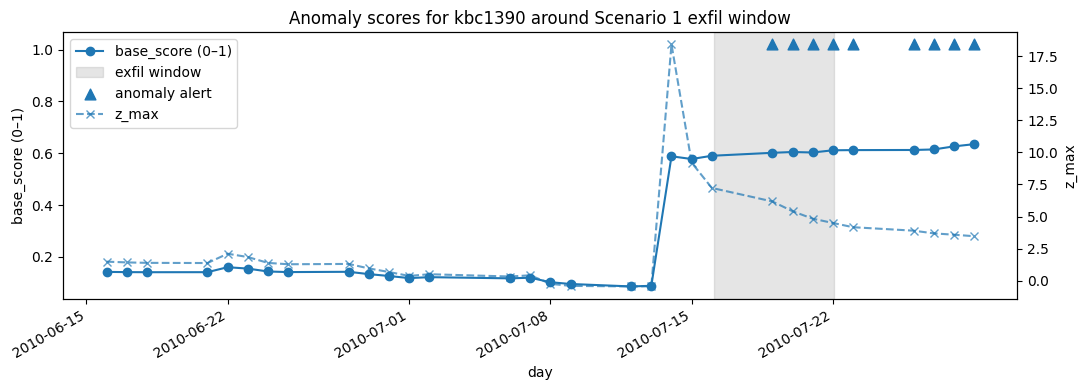


Sample anomaly alerts (max 10):


,day,score,reason
5023,2010-07-19,0.521591,anomaly:isolation_forest
5169,2010-07-20,0.520833,anomaly:isolation_forest
5312,2010-07-21,0.525997,anomaly:isolation_forest
5452,2010-07-22,0.547003,anomaly:isolation_forest
5589,2010-07-23,0.546544,anomaly:isolation_forest
5764,2010-07-26,0.546253,anomaly:isolation_forest
5903,2010-07-27,0.547225,anomaly:isolation_forest
6043,2010-07-28,0.546634,anomaly:isolation_forest
6180,2010-07-29,0.542618,anomaly:isolation_forest


In [9]:
# Example: inspect the first Scenario 1 user
example_user = s1_df["user_key"].iloc[3]
inspect_user(example_user, pre_days=30, post_days=7)

[1/29] User: kew0198


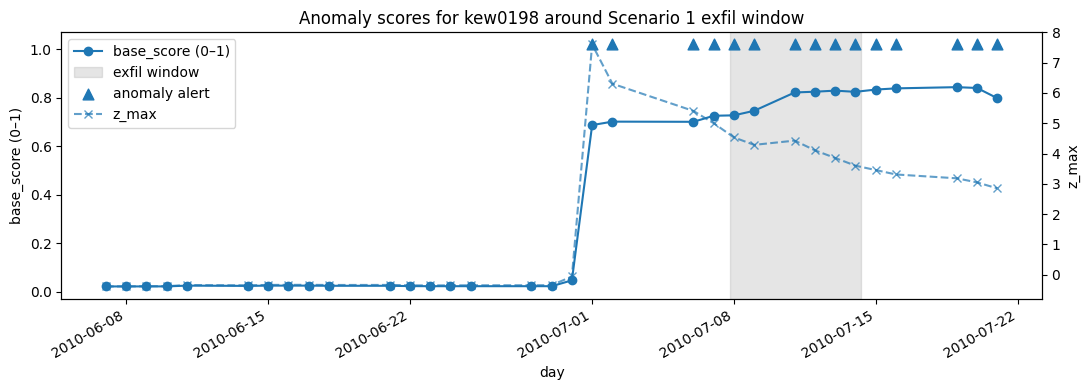

[2/29] User: das1320


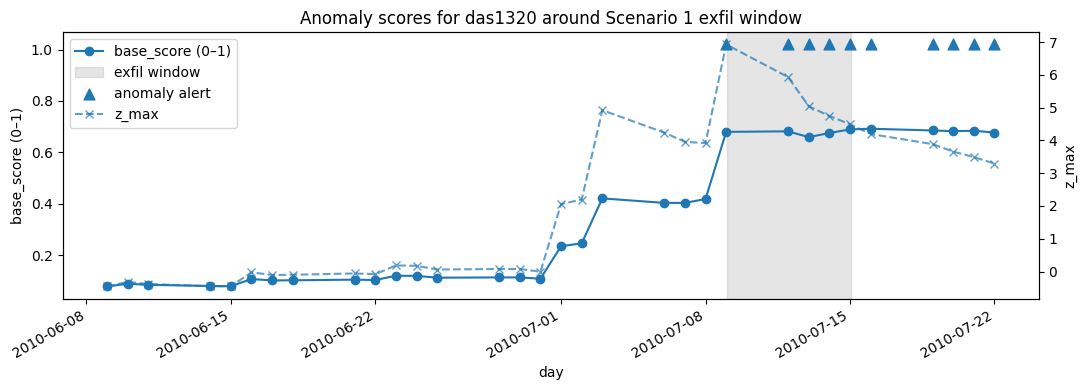

[3/29] User: epg1196


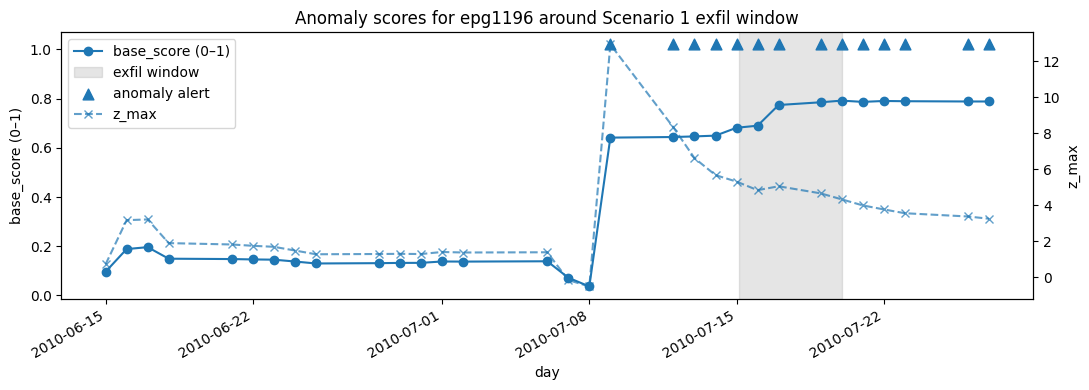

[4/29] User: kbc1390


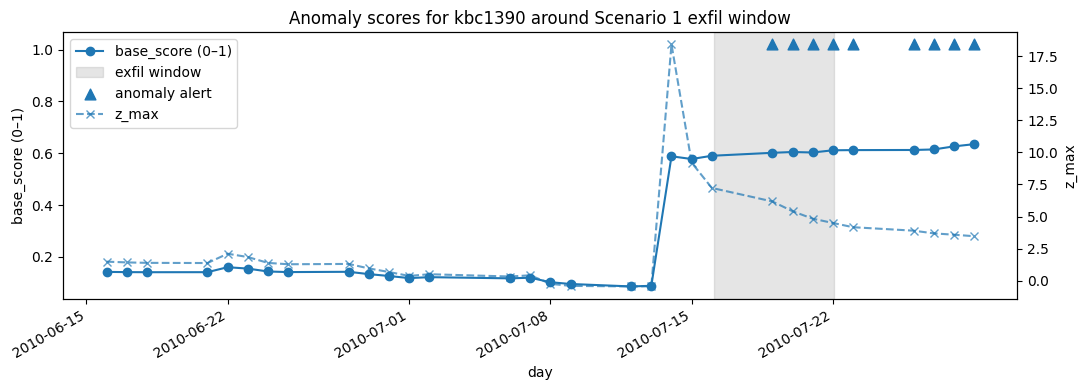

[5/29] User: gfm1815


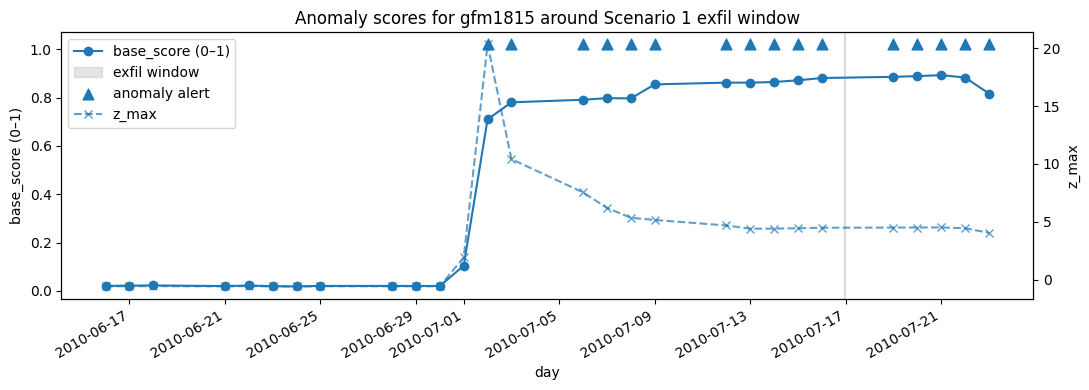

[6/29] User: saf1942


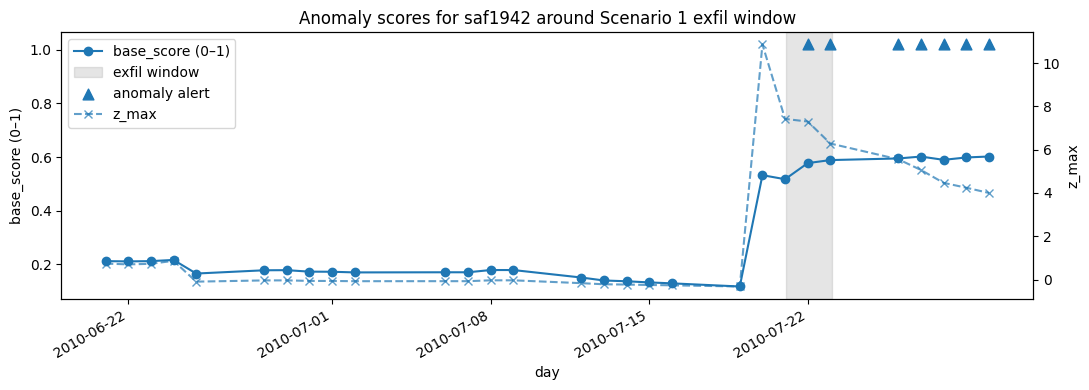

[7/29] User: pbc0077


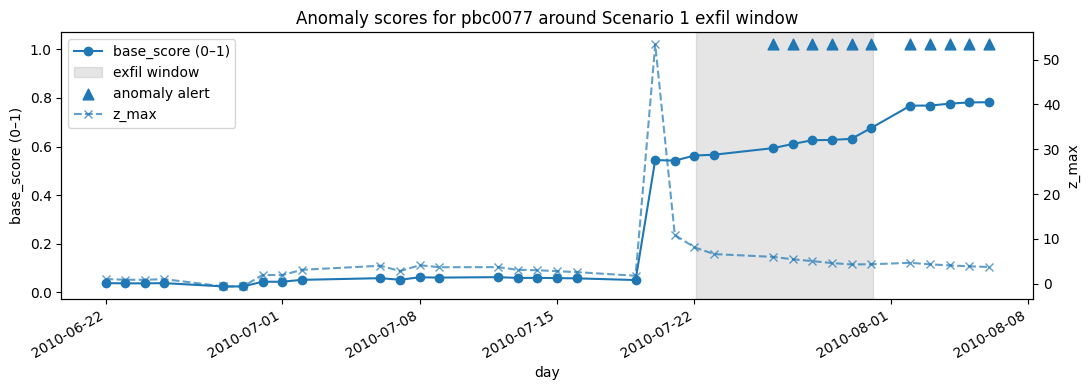

[8/29] User: alt1465


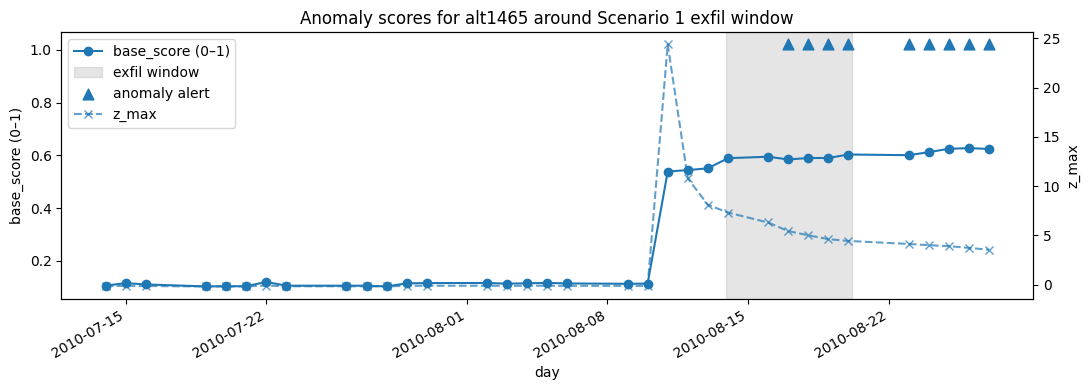

[9/29] User: sll0193


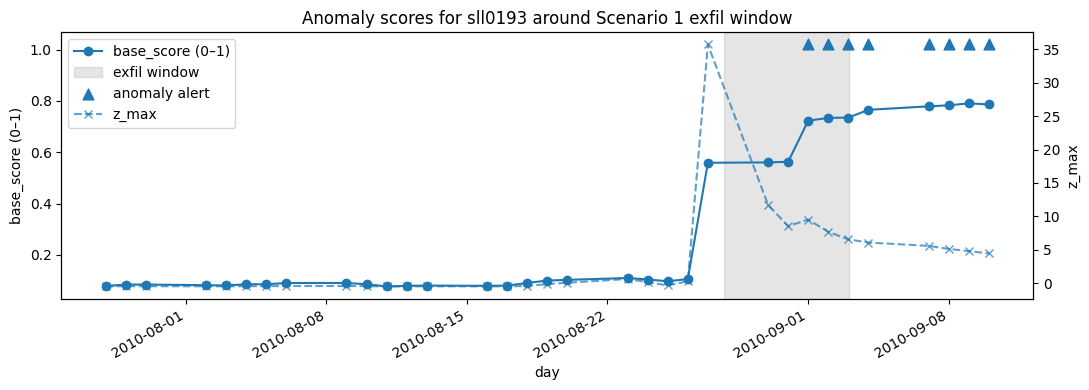

[10/29] User: ihc0561


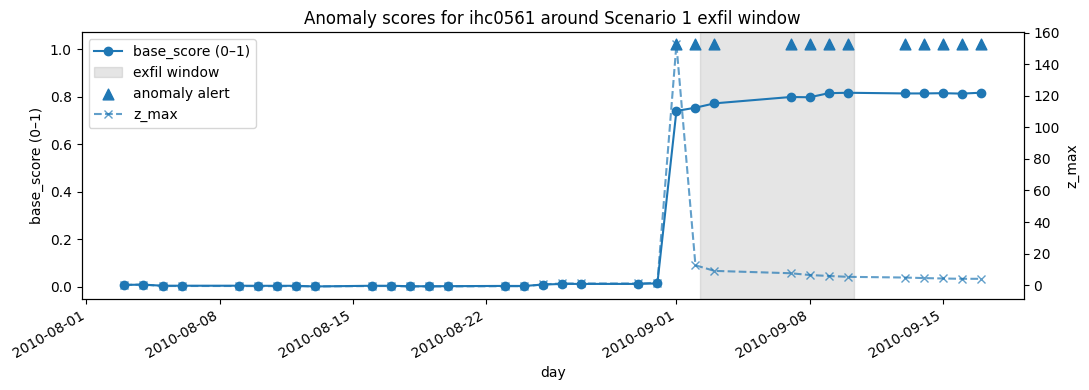

[11/29] User: jkb0287


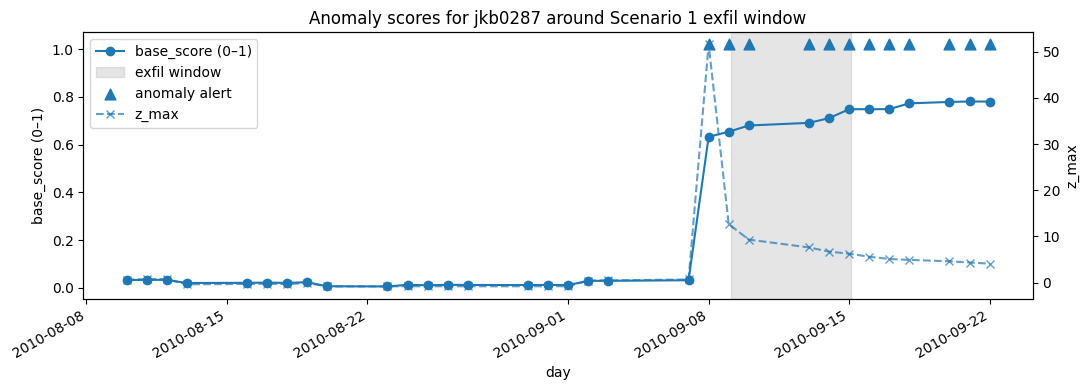

[12/29] User: dnj0740


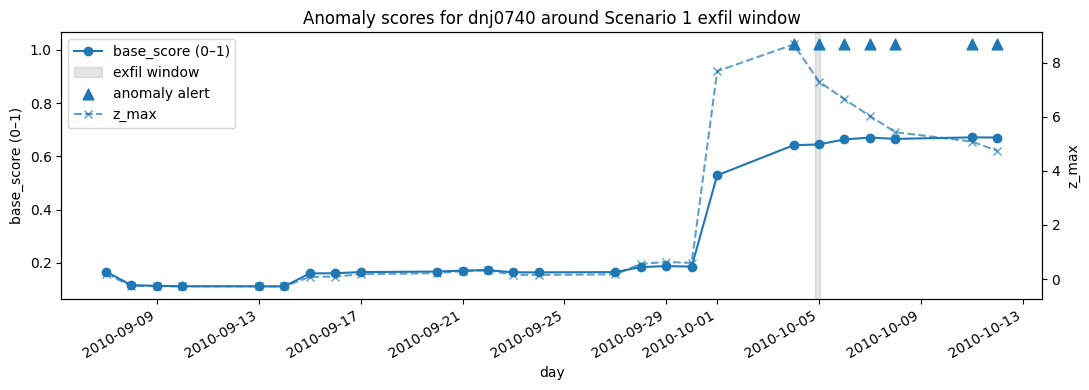

[13/29] User: mib0203


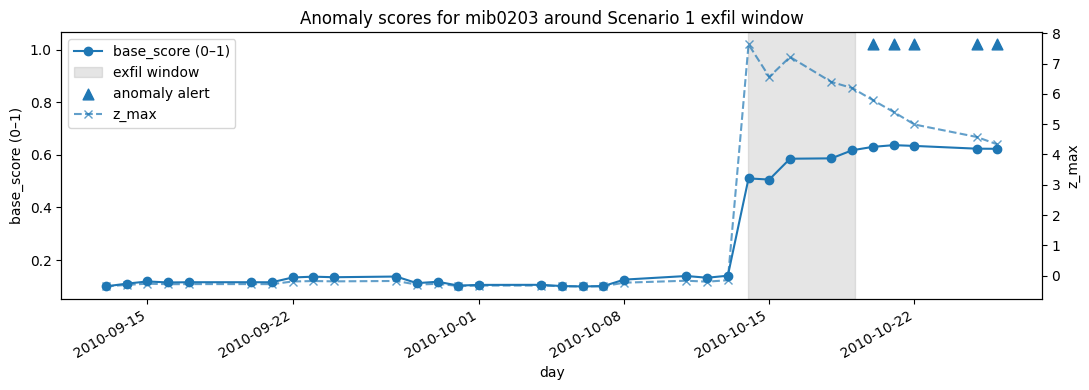

[14/29] User: ref1924


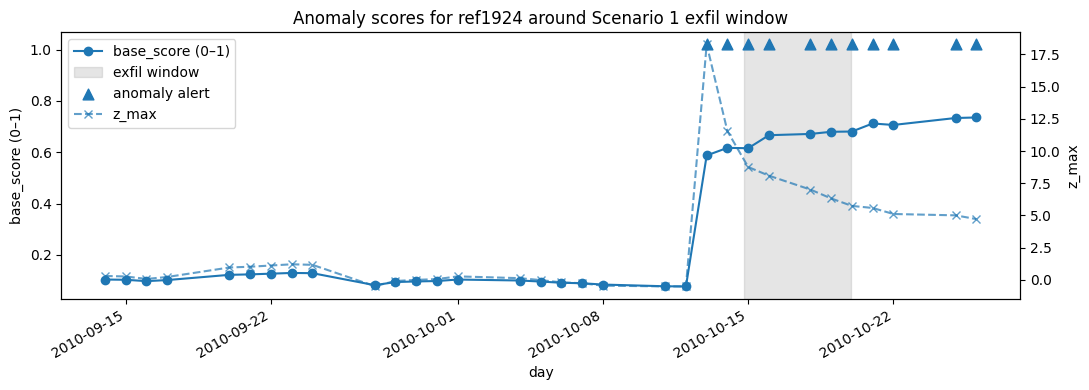

[15/29] User: ayg1697


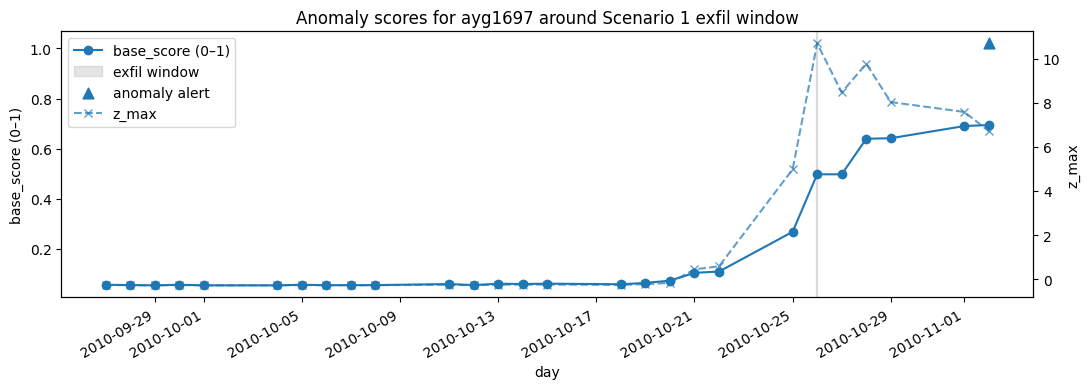

[16/29] User: isw0738


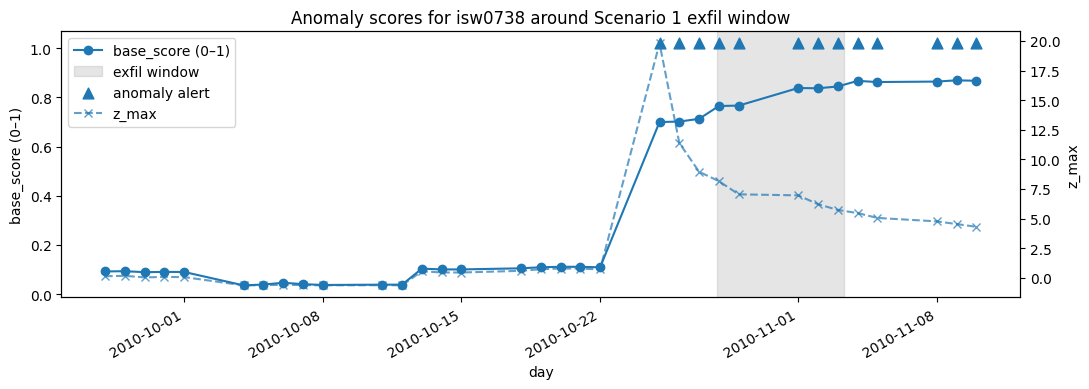

[17/29] User: fzg0389


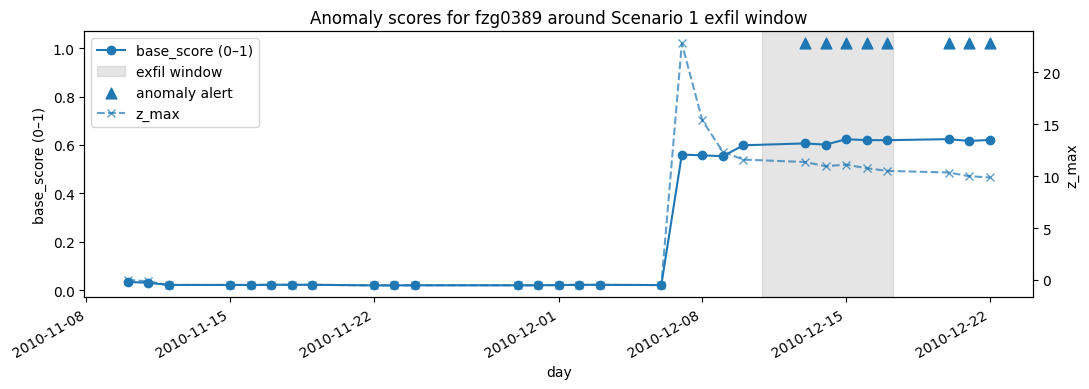

[18/29] User: zkp0542


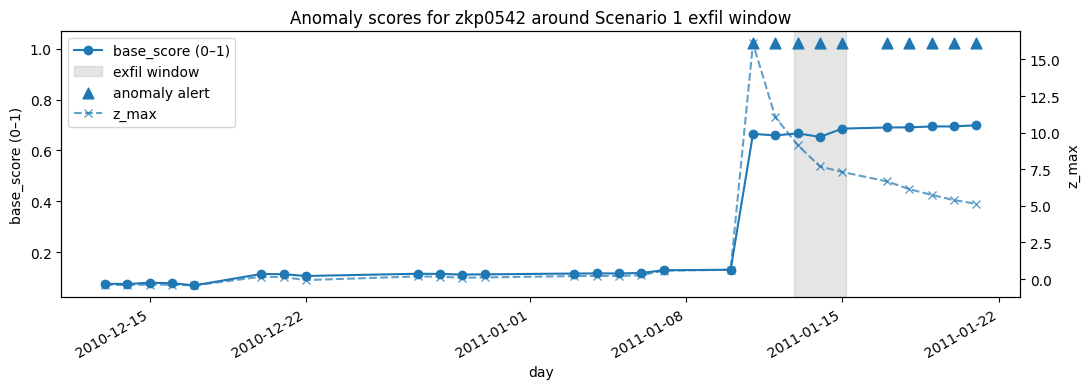

[19/29] User: pth0005


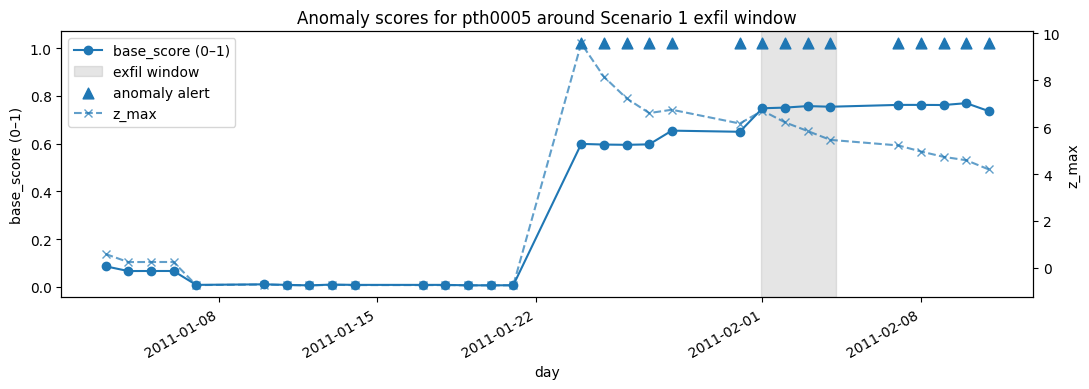

[20/29] User: alw0764


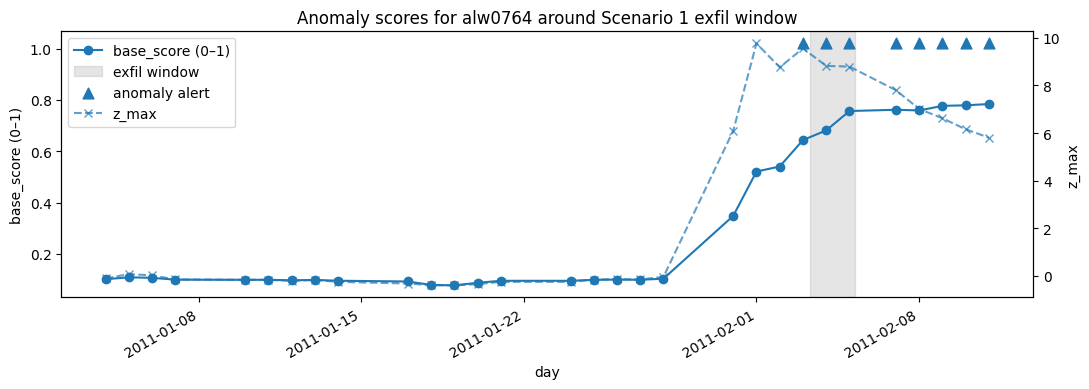

[21/29] User: elt1370


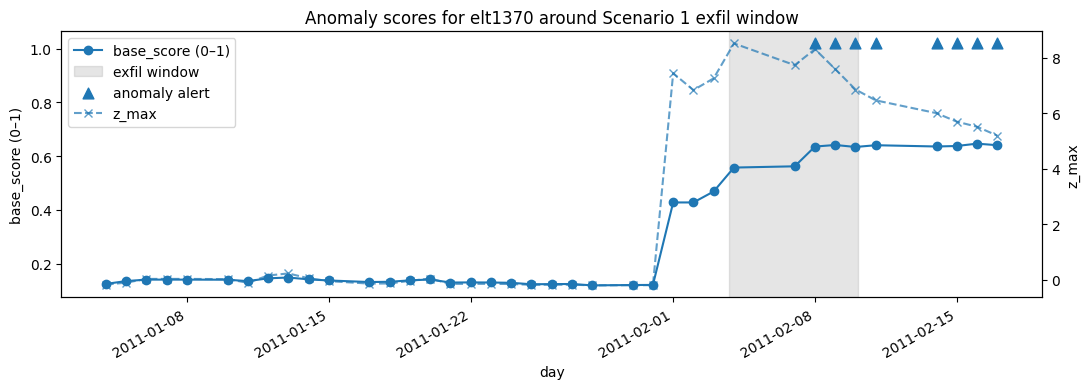

[22/29] User: niv1608


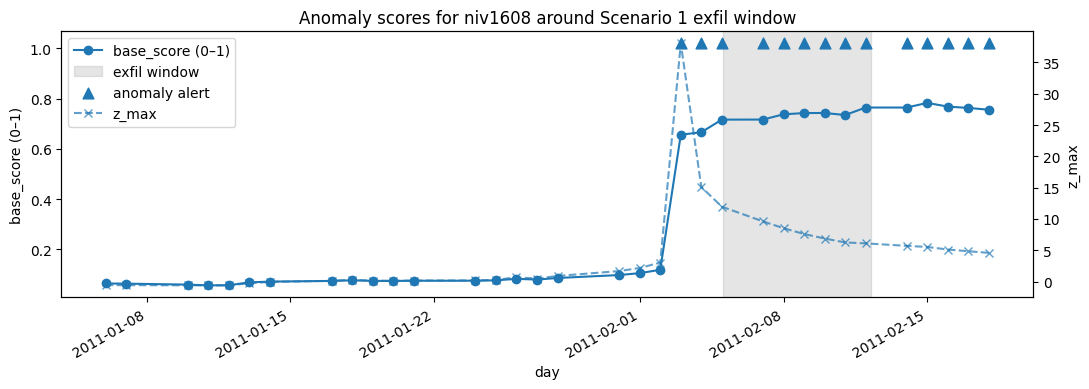

[23/29] User: jup1472


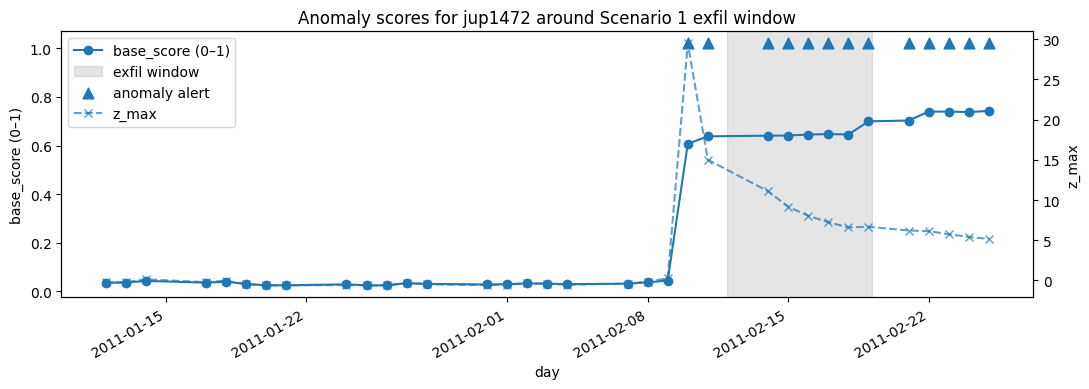

[24/29] User: whb1247


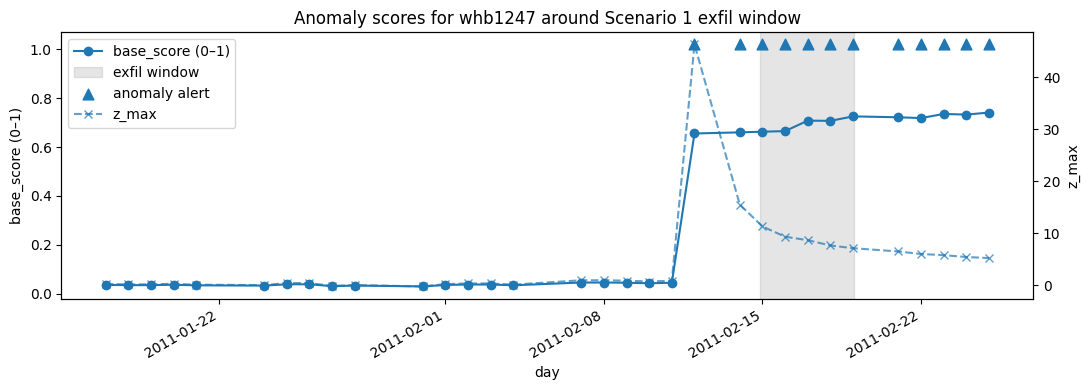

[25/29] User: tmc0934


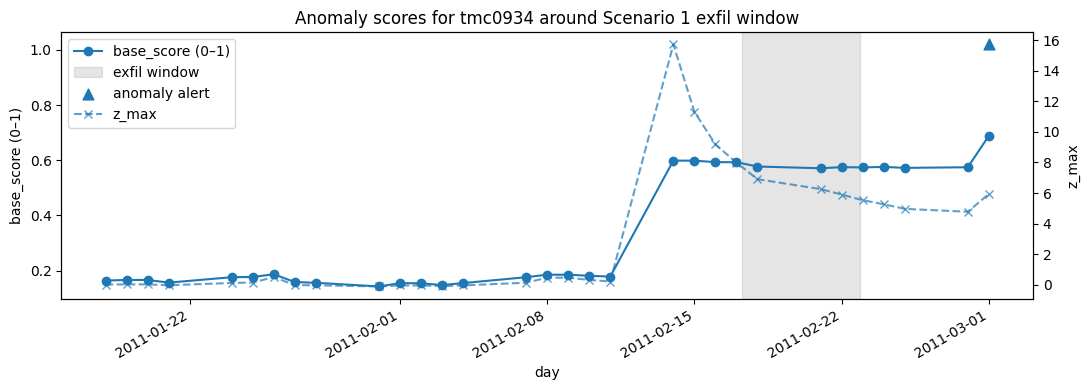

[26/29] User: wsk1857


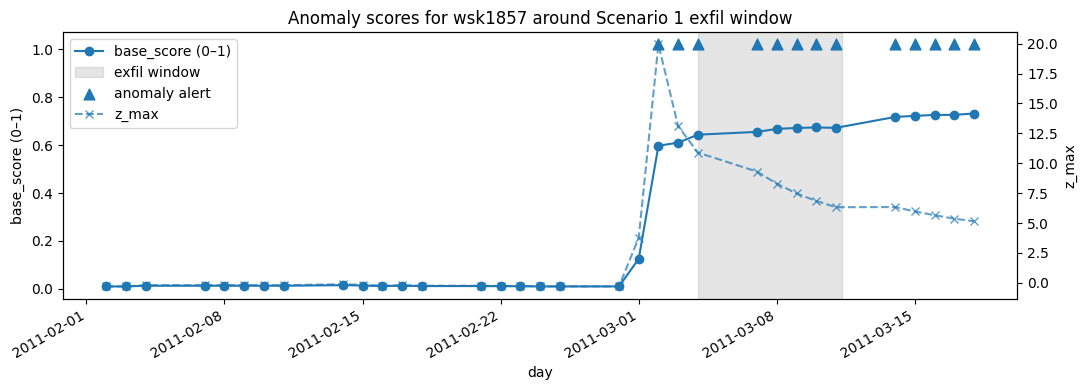

[27/29] User: etw0002


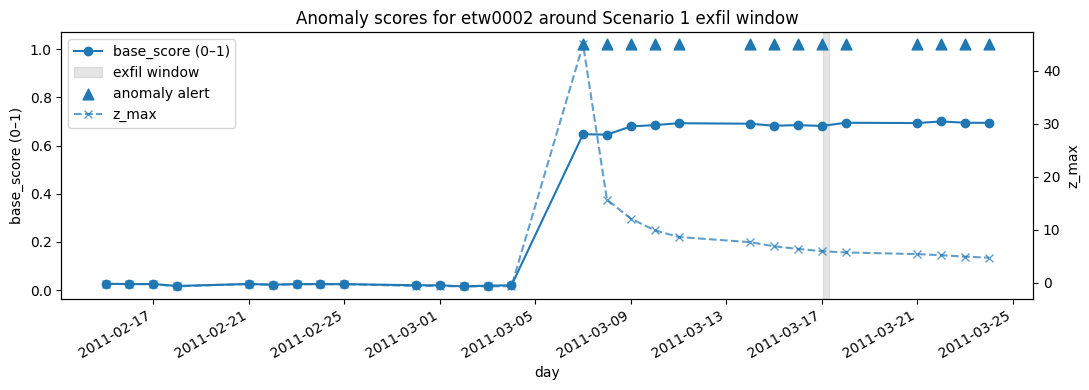

[28/29] User: www0701


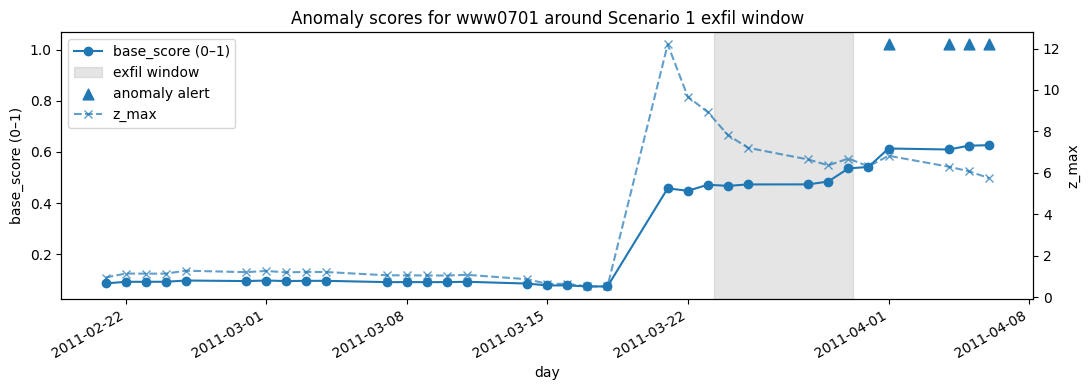

[29/29] User: vah1292


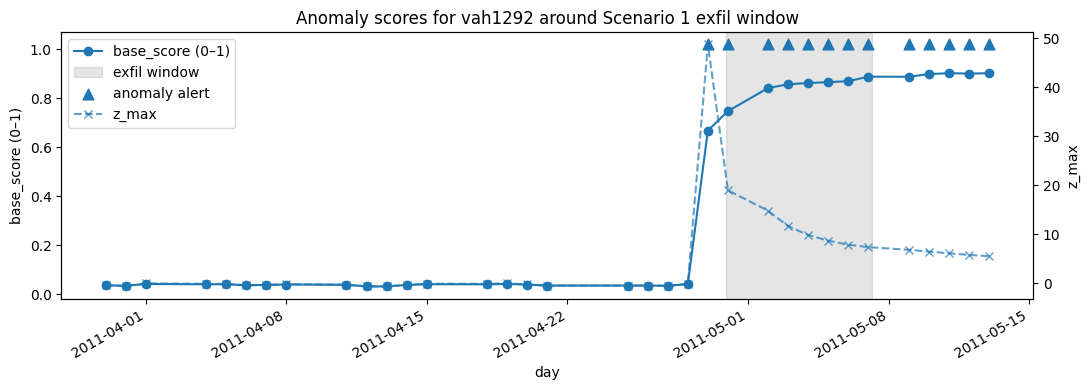


=== Per-insider summary ===


,windows_in_range,alerts_in_range,max_base_score,mean_base_score,max_z_max,alerts_per_window
user_key,,,,,,
ihc0561,33,12,0.816965,0.294123,152.477199,0.363636
pbc0077,34,11,0.782278,0.317122,53.383829,0.323529
jkb0287,32,12,0.781055,0.285299,51.542954,0.375000
vah1292,34,13,0.902667,0.350098,48.693090,0.382353
whb1247,32,12,0.741259,0.287044,46.323481,0.375000
etw0002,28,14,0.700252,0.352770,44.944082,0.500000
niv1608,34,14,0.783193,0.348409,38.043686,0.411765
sll0193,33,8,0.790482,0.295313,35.738534,0.242424
jup1472,34,13,0.742364,0.279812,29.474821,0.382353


In [10]:
summary_df = inspect_all_insiders(pre_days=30, post_days=7)

In [11]:
def compute_s1_anomaly_metrics_earlyaware(pre_days: int = 30, post_days: int = 7) -> pd.DataFrame:
    """
    Computes metrics for anomaly detector on S1 users with a FAIR treatment of early-warning alerts.
    
    Zones:
      - DURING exfil window: TP / FN
      - BEFORE exfil window (start-K .. start-1): Early Warning Positives (EWP)
      - Outside both: FP / TN
    """

    records = []

    for _, row in s1_df.iterrows():
        user_key     = row["user_key"]
        exfil_start  = row["exfil_start"].date()
        exfil_end    = row["exfil_end"].date()

        early_start  = exfil_start - timedelta(days=pre_days)
        early_end    = exfil_start - timedelta(days=1)
        late_end     = exfil_end + timedelta(days=post_days)

        # Window where we gather z-scores
        user_scores = zscores_df[
            (zscores_df["user_key"] == user_key) &
            (zscores_df["day"] >= pd.to_datetime(early_start)) &
            (zscores_df["day"] <= pd.to_datetime(late_end))
        ].copy()

        if user_scores.empty:
            continue

        # Alerts for this user
        user_alerts = alerts_df[
            (alerts_df["user_key"] == user_key) &
            (alerts_df["day"] >= pd.to_datetime(early_start)) &
            (alerts_df["day"] <= pd.to_datetime(late_end))
        ].copy()

        alert_days = set(user_alerts["day"].dt.date)

        # Counters
        TP = 0
        FN = 0
        FP = 0
        TN = 0
        EWP = 0   # early-warning positives

        for _, w in user_scores.iterrows():
            d = w["day"].date()
            is_alert = d in alert_days

            if exfil_start <= d <= exfil_end:
                # True exfil window
                if is_alert:
                    TP += 1
                else:
                    FN += 1

            elif early_start <= d <= early_end:
                # Early-warning region
                if is_alert:
                    EWP += 1
                # otherwise nothing (not penalized, not rewarded)

            else:
                # Outside both early and exfil windows → real non-exfil
                if is_alert:
                    FP += 1
                else:
                    TN += 1

        # Lead-time
        early_alert_days = [d for d in alert_days if early_start <= d <= early_end]
        lead_time = None
        if early_alert_days:
            first_early = min(early_alert_days)
            lead_time = (exfil_start - first_early).days

        records.append({
            "user_key": user_key,
            "TP": TP,
            "FN": FN,
            "FP": FP,
            "TN": TN,
            "EWP": EWP,
            "lead_time_days": lead_time,
        })

    df = pd.DataFrame(records).set_index("user_key")

    # Global metrics
    TP = df["TP"].sum()
    FN = df["FN"].sum()
    FP = df["FP"].sum()
    EWP = df["EWP"].sum()

    recall = TP / (TP + FN) if (TP + FN) > 0 else float("nan")
    precision_strict = TP / (TP + FP) if (TP + FP) > 0 else float("nan")
    precision_with_ewp = (TP + EWP) / (TP + EWP + FP) if (TP + EWP + FP) > 0 else float("nan")

    print("=== Scenario 1 Anomaly Metrics (early-aware) ===")
    print(f"TP (exfil-day alerts)                 : {TP}")
    print(f"FN (missed exfil days)                : {FN}")
    print(f"EWP (early warning positives)         : {EWP}")
    print(f"FP (alerts outside both windows)      : {FP}")
    print()
    print(f"Recall on exfil days                  : {recall:.3f}")
    print(f"Precision (strict TP/(TP+FP))         : {precision_strict:.3f}")
    print(f"Precision counting early warnings     : {precision_with_ewp:.3f}")
    print()

    # Lead-time summary
    lt = df["lead_time_days"].dropna()
    if not lt.empty:
        print("Lead-time stats (days before exfil):")
        print(f"  count : {len(lt)}")
        print(f"  min   : {lt.min():.1f}")
        print(f"  median: {lt.median():.1f}")
        print(f"  max   : {lt.max():.1f}")

    return df

# Run it
earlyaware_df = compute_s1_anomaly_metrics_earlyaware(pre_days=30, post_days=7)
display(earlyaware_df)


=== Scenario 1 Anomaly Metrics (early-aware) ===
TP (exfil-day alerts)                 : 116
FN (missed exfil days)                : 32
EWP (early warning positives)         : 42
FP (alerts outside both windows)      : 135

Recall on exfil days                  : 0.784
Precision (strict TP/(TP+FP))         : 0.462
Precision counting early warnings     : 0.539

Lead-time stats (days before exfil):
  count : 14
  min   : 1.0
  median: 2.0
  max   : 14.0


,TP,FN,FP,TN,EWP,lead_time_days
user_key,,,,,,
kew0198,7,0,5,0,3,6.0
das1320,5,0,5,0,0,NaN
epg1196,5,0,5,0,4,6.0
kbc1390,4,1,5,0,0,NaN
gfm1815,1,0,5,0,10,14.0
saf1942,2,1,5,0,0,NaN
pbc0077,6,2,5,0,0,NaN
alt1465,4,3,5,0,0,NaN
sll0193,3,3,5,0,0,NaN


In [12]:
def compute_noninsider_fp_metrics():
    """
    Evaluate false-positive behavior of the anomaly detector
    on ALL non-insider users.
    
    Metrics per user:
      - total_days
      - fp_days       (# days with anomaly alert)
      - fp_rate       (fp_days / total_days)
      - max_z_max
      - mean_z_max

    Returns:
      DataFrame indexed by user_key with per-user FP metrics.
    """

    insider_users = set(s1_df["user_key"])
    all_users = set(zscores_df["user_key"])
    non_insiders = sorted(all_users - insider_users)

    records = []

    # Pre-index the alerts for speed
    anomaly_alerts = alerts_df[alerts_df["detector"] == "anomaly"].copy()
    alert_groups = {
        k: set(v["day"].dt.date)
        for k, v in anomaly_alerts.groupby("user_key")
    }

    for user in non_insiders:
        user_scores = zscores_df[zscores_df["user_key"] == user]
        if user_scores.empty:
            continue

        total_days = len(user_scores)
        days = user_scores["day"].dt.date.tolist()

        alert_days = alert_groups.get(user, set())
        fp_days = sum(d in alert_days for d in days)

        records.append({
            "user_key": user,
            "total_days": total_days,
            "fp_days": fp_days,
            "fp_rate": fp_days / total_days,
            "max_z_max": user_scores["z_max"].max(),
            "mean_z_max": user_scores["z_max"].mean(),
        })

    df = pd.DataFrame(records).set_index("user_key")

    print("=== Non-insider false-positive evaluation ===")
    print(f"Total non-insiders evaluated : {len(df)}")
    print(f"Users with ≥1 anomaly alert  : {int((df['fp_days'] > 0).sum())}")
    print(f"Percentage triggering alerts : {(df['fp_days'] > 0).mean() * 100:.2f}%")

    print("\nFP rate summary (% of days anomaly barked):")
    print(df["fp_rate"].describe())

    print("\nTop 20 noisiest non-insiders by fp_rate:")
    display(df.sort_values("fp_rate", ascending=False).head(20))

    return df

# Run it
noninsider_df = compute_noninsider_fp_metrics()


=== Non-insider false-positive evaluation ===
Total non-insiders evaluated : 1971
Users with ≥1 anomaly alert  : 340
Percentage triggering alerts : 17.25%

FP rate summary (% of days anomaly barked):
count    1971.000000
mean        0.052849
std         0.168871
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.723881
Name: fp_rate, dtype: float64

Top 20 noisiest non-insiders by fp_rate:


,total_days,fp_days,fp_rate,max_z_max,mean_z_max
user_key,,,,,
aab1302,402,291,0.723881,3.340054,2.058112
nva1748,434,314,0.723502,3.910889,2.651899
sss1129,365,263,0.720548,3.517167,3.000902
lns0317,482,347,0.719917,9.296428,2.303935
cjm0410,351,252,0.717949,3.344628,2.515562
hbr1528,482,346,0.717842,3.209722,2.502178
pmm1117,379,272,0.717678,3.648802,2.979277
smk1323,347,249,0.717579,5.405605,2.666986
gat1343,488,350,0.717213,6.240229,2.216529
